Project folders created.
BASE_DIR: /content/component_2_emotion_propagation_fixed
Loading GoEmotions dataset...


README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Loaded using google-research-datasets/go_emotions
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Sample row:
{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}
Dataset columns: ['text', 'labels', 'id']
Dataset features: {'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}

Total labels: 28
['admiration', 'amusement', '

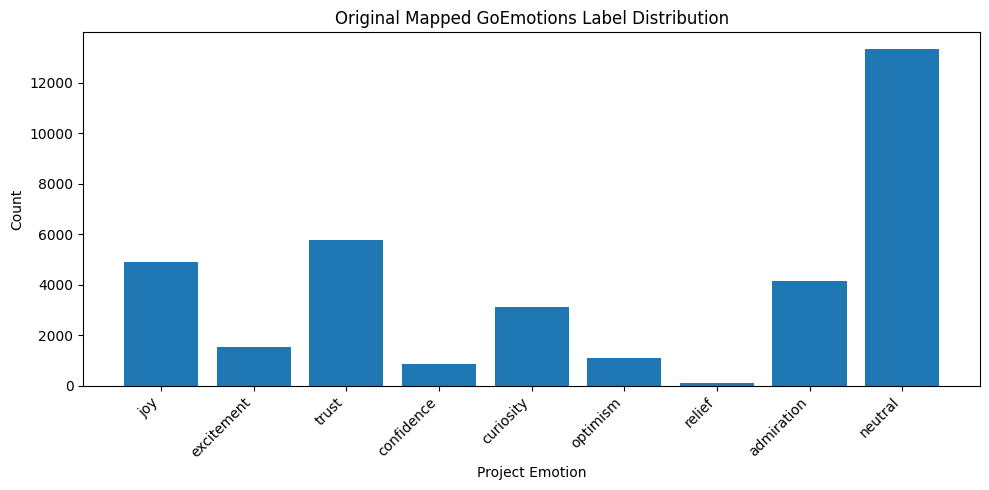

/tmp/ipykernel_2307/830825552.py:334: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), MAX_PER_CLASS), random_state=RANDOM_STATE))


Balanced training shape: (18596, 4)

Balanced label distribution:
label
neutral       3000
curiosity     3000
joy           3000
trust         3000
admiration    3000
excitement    1520
optimism      1104
confidence     866
relief         106
Name: count, dtype: int64


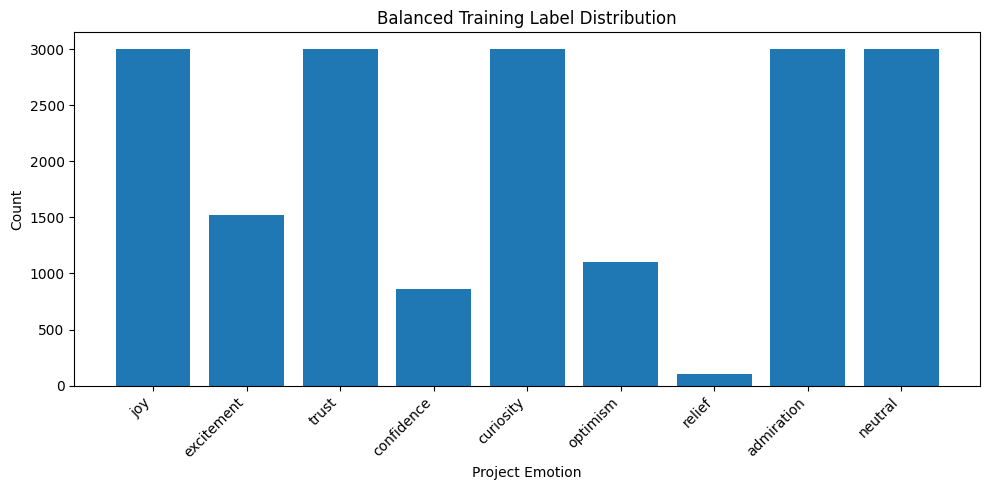

X_train: (18596,)
X_val: (4357,)
X_test: (4298,)
Training classes:
['admiration', 'confidence', 'curiosity', 'excitement', 'joy', 'neutral', 'optimism', 'relief', 'trust']
Training fixed emotion classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training completed.
Model classes:
['admiration' 'confidence' 'curiosity' 'excitement' 'joy' 'neutral'
 'optimism' 'relief' 'trust']
Validation Accuracy: 0.5309
Validation Macro F1: 0.4426
Validation Weighted F1: 0.5548
Test Accuracy: 0.5195
Test Macro F1: 0.4293
Test Weighted F1: 0.5417

Classification Report:
              precision    recall  f1-score   support

         joy       0.74      0.71      0.73       550
  excitement       0.30      0.52      0.38       192
       trust       0.66      0.50      0.57       732
  confidence       0.13      0.39      0.20       123
   curiosity       0.27      0.41      0.32       389
    optimism       0.34      0.68      0.46       133
      relief       0.02      0.14      0.04         7
  admiration       0.61      0.62      0.62       504
     neutral       0.69      0.46      0.55      1668

    accuracy                           0.52      4298
   macro avg       0.42      0.49      0.43      4298
weighted avg       0.60      0.52    

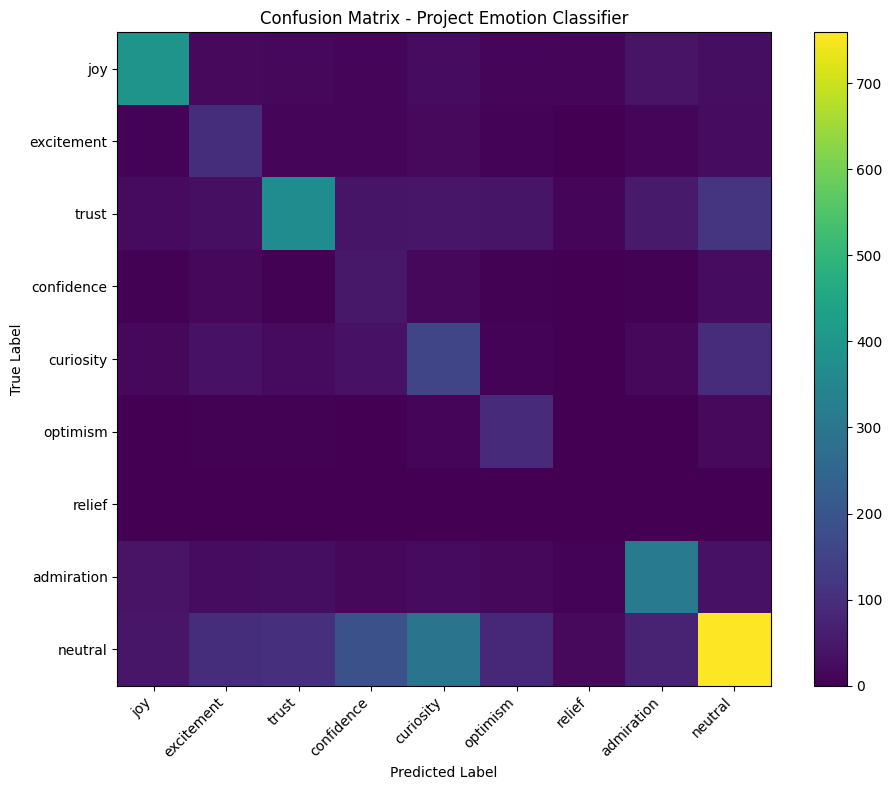


TEXT: I love this so much! It made my day and I feel so happy.
      emotion     score
0         joy  0.949065
1  excitement  0.021047
2       trust  0.012052
3  admiration  0.006715
4      relief  0.002898

TEXT: This is unacceptable and it makes me furious.
      emotion     score
0   curiosity  0.197129
1      relief  0.168587
2     neutral  0.140051
3  confidence  0.102953
4       trust  0.092410

TEXT: I feel excited to try this new product today.
      emotion     score
0  excitement  0.792049
1       trust  0.046346
2     neutral  0.036806
3    optimism  0.034338
4   curiosity  0.023158

TEXT: This service feels reliable, secure, and trustworthy.
      emotion     score
0     neutral  0.197987
1  confidence  0.186106
2   curiosity  0.183393
3       trust  0.103617
4  admiration  0.079159

TEXT: I am curious to discover how this works.
      emotion     score
0   curiosity  0.749849
1     neutral  0.061017
2       trust  0.050056
3  excitement  0.031190
4  admiration  0.028586



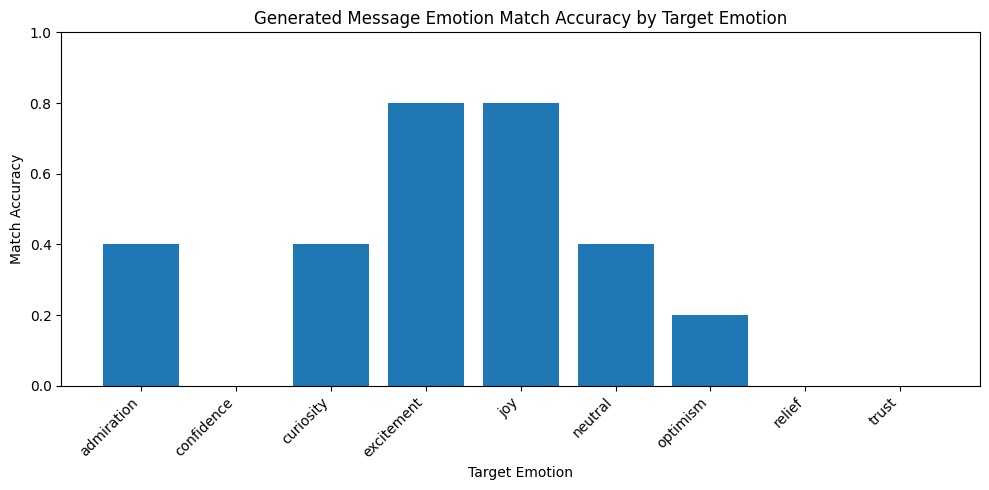

User study template saved:
/content/component_2_emotion_propagation_fixed/outputs/user_study_dataset_template.csv


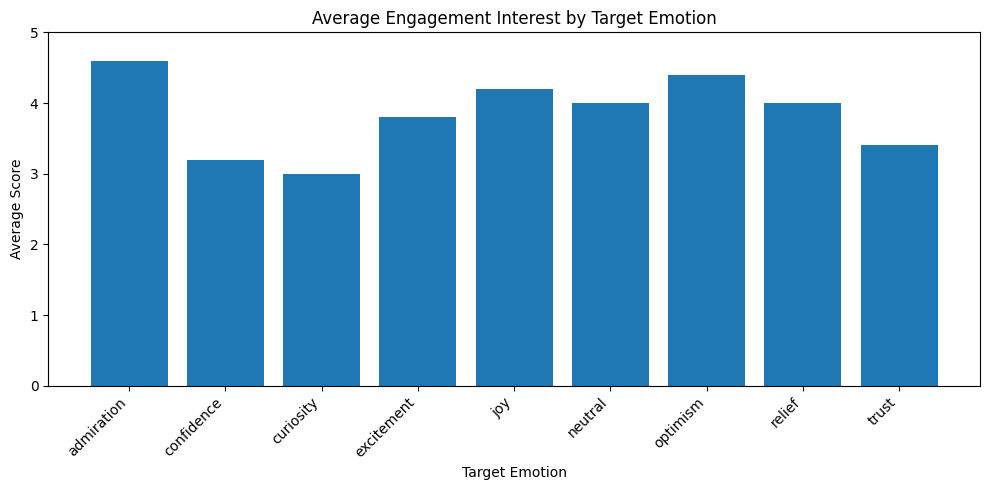

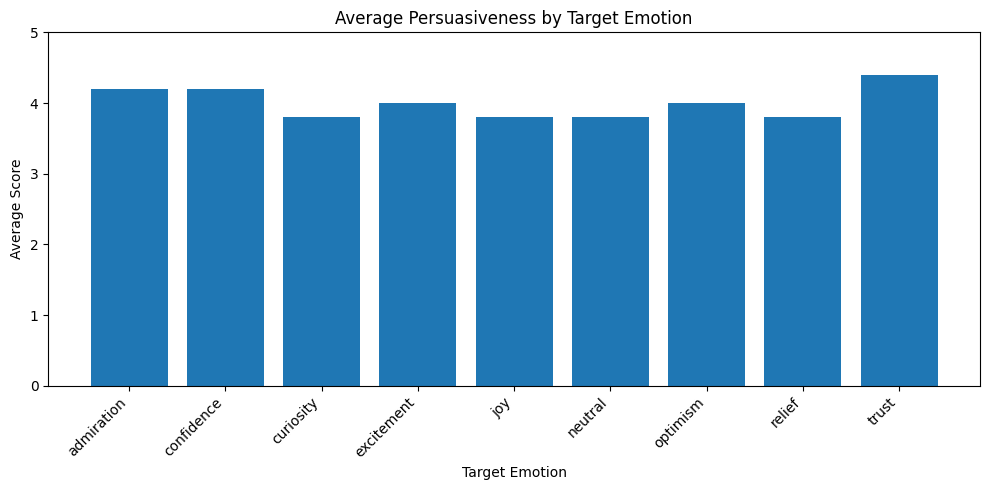

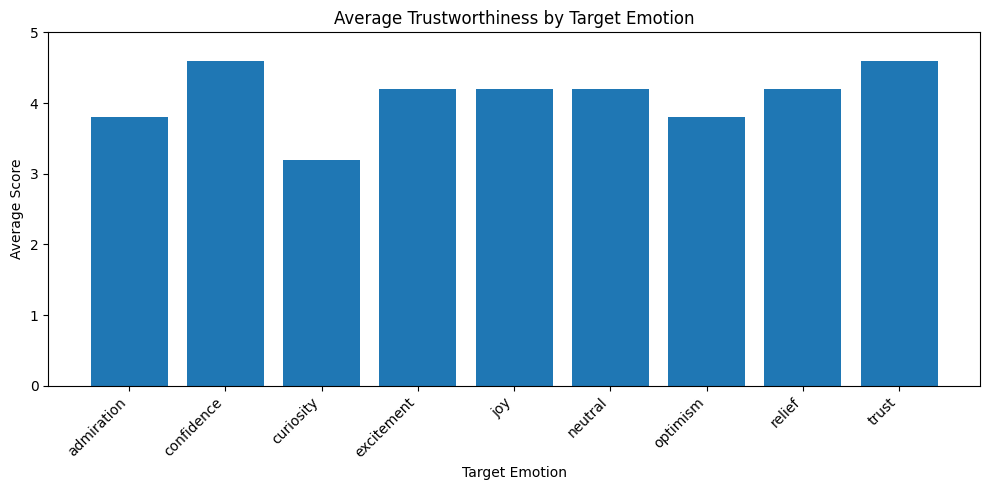

ZIP file created:
/content/component_2_fixed_emotion_agent_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model ZIP created:
/content/fixed_emotion_model_files.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# COMPONENT 2: EMOTION PROPAGATION AGENT
# FULL CORRECTED GOOGLE COLAB CODE
# WITH HUGGING FACE DATASET LOADING FIX
# ============================================================

# ============================================================
# 1. INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q datasets scikit-learn pandas numpy matplotlib joblib kaggle


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import json
import glob
import shutil
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

pd.set_option("display.max_colwidth", 200)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# ============================================================
# 3. CREATE PROJECT FOLDERS
# ============================================================

BASE_DIR = "/content/component_2_emotion_propagation_fixed"
DATA_DIR = f"{BASE_DIR}/datasets"
OUTPUT_DIR = f"{BASE_DIR}/outputs"
MODEL_DIR = f"{BASE_DIR}/models"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Project folders created.")
print("BASE_DIR:", BASE_DIR)


# ============================================================
# 4. LOAD GOEMOTIONS DATASET - FIXED VERSION
# ============================================================

print("Loading GoEmotions dataset...")

try:
    dataset = load_dataset("google-research-datasets/go_emotions", "simplified")
    print("Loaded using google-research-datasets/go_emotions")

except Exception as e1:
    print("First loading method failed:")
    print(e1)

    try:
        dataset = load_dataset("mrm8488/goemotions")
        print("Loaded using mrm8488/goemotions")

    except Exception as e2:
        print("Second loading method failed:")
        print(e2)

        try:
            dataset = load_dataset("SetFit/go_emotions")
            print("Loaded using SetFit/go_emotions")

        except Exception as e3:
            print("Third loading method failed:")
            print(e3)
            raise RuntimeError("Could not load GoEmotions from available Hugging Face sources.")

print(dataset)
print("\nSample row:")
print(dataset["train"][0])


# ============================================================
# 5. EXTRACT LABEL NAMES - FIXED VERSION
# ============================================================

def extract_label_names(dataset):
    features = dataset["train"].features

    print("Dataset columns:", dataset["train"].column_names)
    print("Dataset features:", features)

    if "labels" in features:
        labels_feature = features["labels"]

        if hasattr(labels_feature, "feature") and hasattr(labels_feature.feature, "names"):
            return labels_feature.feature.names

        if hasattr(labels_feature, "names"):
            return labels_feature.names

    if "label" in features:
        label_feature = features["label"]

        if hasattr(label_feature, "names"):
            return label_feature.names

    # Fallback official GoEmotions labels
    return [
        "admiration", "amusement", "anger", "annoyance", "approval",
        "caring", "confusion", "curiosity", "desire", "disappointment",
        "disapproval", "disgust", "embarrassment", "excitement", "fear",
        "gratitude", "grief", "joy", "love", "nervousness", "optimism",
        "pride", "realization", "relief", "remorse", "sadness",
        "surprise", "neutral"
    ]


label_names = extract_label_names(dataset)

print("\nTotal labels:", len(label_names))
print(label_names)


# ============================================================
# 6. CONVERT GOEMOTIONS DATASET TO DATAFRAME
# ============================================================

def convert_split_to_df(split_name):
    rows = []

    for item in dataset[split_name]:
        text = item.get("text", "")

        if "labels" in item:
            label_ids = item["labels"]

            if isinstance(label_ids, int):
                label_ids = [label_ids]

            original_labels = []

            for label_id in label_ids:
                try:
                    original_labels.append(label_names[int(label_id)])
                except:
                    pass

        elif "label" in item:
            label_id = item["label"]

            if isinstance(label_id, int):
                try:
                    original_labels = [label_names[label_id]]
                except:
                    original_labels = ["neutral"]
            else:
                original_labels = [str(label_id)]

        else:
            original_labels = ["neutral"]

        if len(original_labels) == 0:
            original_labels = ["neutral"]

        rows.append({
            "text": text,
            "original_labels": original_labels,
            "split": split_name
        })

    return pd.DataFrame(rows)


train_df = convert_split_to_df("train")

if "validation" in dataset:
    val_df = convert_split_to_df("validation")
elif "valid" in dataset:
    val_df = convert_split_to_df("valid")
else:
    val_df = train_df.sample(5000, random_state=RANDOM_STATE).reset_index(drop=True)

if "test" in dataset:
    test_df = convert_split_to_df("test")
else:
    test_df = train_df.sample(5000, random_state=RANDOM_STATE).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


# ============================================================
# 7. DEFINE PROJECT EMOTIONS
# ============================================================

project_labels = [
    "joy",
    "excitement",
    "trust",
    "confidence",
    "curiosity",
    "optimism",
    "relief",
    "admiration",
    "neutral"
]

print("Project labels:")
print(project_labels)


# ============================================================
# 8. MAP GOEMOTIONS LABELS TO PROJECT EMOTIONS
# ============================================================

emotion_mapping = {
    "joy": "joy",
    "amusement": "joy",
    "love": "joy",

    "excitement": "excitement",
    "surprise": "excitement",

    "approval": "trust",
    "gratitude": "trust",
    "caring": "trust",

    "pride": "confidence",
    "realization": "confidence",

    "curiosity": "curiosity",
    "confusion": "curiosity",

    "optimism": "optimism",

    "relief": "relief",

    "admiration": "admiration",

    "neutral": "neutral"
}


def map_to_project_label(original_labels):
    if not isinstance(original_labels, list):
        return None

    # Prefer non-neutral labels
    for label in original_labels:
        if label in emotion_mapping and emotion_mapping[label] != "neutral":
            return emotion_mapping[label]

    # Use neutral only if no useful emotion exists
    for label in original_labels:
        if label == "neutral":
            return "neutral"

    return None


train_df["label"] = train_df["original_labels"].apply(map_to_project_label)
val_df["label"] = val_df["original_labels"].apply(map_to_project_label)
test_df["label"] = test_df["original_labels"].apply(map_to_project_label)

train_df = train_df.dropna(subset=["label"]).reset_index(drop=True)
val_df = val_df.dropna(subset=["label"]).reset_index(drop=True)
test_df = test_df.dropna(subset=["label"]).reset_index(drop=True)

print("Mapped train shape:", train_df.shape)
print("Mapped validation shape:", val_df.shape)
print("Mapped test shape:", test_df.shape)

print("\nTraining label distribution:")
print(train_df["label"].value_counts())


# ============================================================
# 9. SAVE PROCESSED DATASETS
# ============================================================

train_df.to_csv(f"{DATA_DIR}/goemotions_train_mapped.csv", index=False)
val_df.to_csv(f"{DATA_DIR}/goemotions_validation_mapped.csv", index=False)
test_df.to_csv(f"{DATA_DIR}/goemotions_test_mapped.csv", index=False)

print("Processed mapped datasets saved.")


# ============================================================
# 10. VISUALIZE ORIGINAL LABEL DISTRIBUTION
# ============================================================

label_counts = train_df["label"].value_counts().reindex(project_labels).fillna(0)

plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values)
plt.title("Original Mapped GoEmotions Label Distribution")
plt.xlabel("Project Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/original_mapped_label_distribution.png", dpi=300)
plt.show()


# ============================================================
# 11. BALANCE TRAINING DATA
# ============================================================

MAX_PER_CLASS = 3000

balanced_train_df = (
    train_df
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_PER_CLASS), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

balanced_train_df = balanced_train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Balanced training shape:", balanced_train_df.shape)
print("\nBalanced label distribution:")
print(balanced_train_df["label"].value_counts())


# ============================================================
# 12. VISUALIZE BALANCED LABEL DISTRIBUTION
# ============================================================

balanced_counts = balanced_train_df["label"].value_counts().reindex(project_labels).fillna(0)

plt.figure(figsize=(10, 5))
plt.bar(balanced_counts.index, balanced_counts.values)
plt.title("Balanced Training Label Distribution")
plt.xlabel("Project Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/balanced_label_distribution.png", dpi=300)
plt.show()


# ============================================================
# 13. PREPARE TRAINING DATA
# ============================================================

X_train = balanced_train_df["text"].astype(str)
y_train = balanced_train_df["label"].astype(str)

X_val = val_df["text"].astype(str)
y_val = val_df["label"].astype(str)

X_test = test_df["text"].astype(str)
y_test = test_df["label"].astype(str)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("Training classes:")
print(sorted(y_train.unique()))


# ============================================================
# 14. TRAIN FIXED SINGLE-LABEL EMOTION CLASSIFIER
# ============================================================

emotion_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=50000,
        min_df=2,
        max_df=0.95
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        multi_class="auto",
        random_state=RANDOM_STATE
    ))
])

print("Training fixed emotion classifier...")
emotion_model.fit(X_train, y_train)
print("Training completed.")

print("Model classes:")
print(emotion_model.classes_)


# ============================================================
# 15. EVALUATE ON VALIDATION SET
# ============================================================

val_pred = emotion_model.predict(X_val)

val_accuracy = accuracy_score(y_val, val_pred)
val_macro_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)
val_weighted_f1 = f1_score(y_val, val_pred, average="weighted", zero_division=0)

print("Validation Accuracy:", round(val_accuracy, 4))
print("Validation Macro F1:", round(val_macro_f1, 4))
print("Validation Weighted F1:", round(val_weighted_f1, 4))

val_report = classification_report(
    y_val,
    val_pred,
    labels=project_labels,
    zero_division=0,
    output_dict=True
)

val_report_df = pd.DataFrame(val_report).transpose()
val_report_df.to_csv(f"{OUTPUT_DIR}/validation_classification_report.csv")

val_report_df


# ============================================================
# 16. EVALUATE ON TEST SET
# ============================================================

test_pred = emotion_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average="macro", zero_division=0)
test_weighted_f1 = f1_score(y_test, test_pred, average="weighted", zero_division=0)

print("Test Accuracy:", round(test_accuracy, 4))
print("Test Macro F1:", round(test_macro_f1, 4))
print("Test Weighted F1:", round(test_weighted_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    test_pred,
    labels=project_labels,
    zero_division=0
))

test_report = classification_report(
    y_test,
    test_pred,
    labels=project_labels,
    zero_division=0,
    output_dict=True
)

test_report_df = pd.DataFrame(test_report).transpose()
test_report_df.to_csv(f"{OUTPUT_DIR}/test_classification_report.csv")

test_report_df


# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, test_pred, labels=project_labels)

cm_df = pd.DataFrame(cm, index=project_labels, columns=project_labels)
cm_df.to_csv(f"{OUTPUT_DIR}/confusion_matrix.csv")

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Project Emotion Classifier")
plt.colorbar()
tick_marks = np.arange(len(project_labels))
plt.xticks(tick_marks, project_labels, rotation=45, ha="right")
plt.yticks(tick_marks, project_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=300)
plt.show()

cm_df


# ============================================================
# 18. PREDICTION FUNCTION
# ============================================================

def predict_emotions(text, top_k=5):
    probs = emotion_model.predict_proba([text])[0]
    classes = list(emotion_model.classes_)

    top_indices = np.argsort(probs)[::-1][:top_k]

    result_df = pd.DataFrame({
        "emotion": [classes[i] for i in top_indices],
        "score": [float(probs[i]) for i in top_indices]
    })

    return result_df


# ============================================================
# 19. SANITY CHECK PREDICTIONS
# ============================================================

sanity_texts = [
    "I love this so much! It made my day and I feel so happy.",
    "This is unacceptable and it makes me furious.",
    "I feel excited to try this new product today.",
    "This service feels reliable, secure, and trustworthy.",
    "I am curious to discover how this works.",
    "This gives me hope for a better future.",
    "This makes my life easier and less stressful.",
    "This premium design looks impressive and elegant.",
    "This product has useful features and good battery life.",
    "This app helps students feel ready and confident before exams.",
    "Explore hidden features and discover a smarter way to learn.",
    "Enjoy fresh food, fast delivery, and happy moments at home."
]

sanity_rows = []

for text in sanity_texts:
    pred_df = predict_emotions(text, top_k=5)

    print("\nTEXT:", text)
    print(pred_df)

    for _, row in pred_df.iterrows():
        sanity_rows.append({
            "text": text,
            "emotion": row["emotion"],
            "score": row["score"]
        })

sanity_df = pd.DataFrame(sanity_rows)
sanity_df.to_csv(f"{OUTPUT_DIR}/sanity_check_predictions.csv", index=False)


# ============================================================
# 20. NEUTRAL COLLAPSE CHECK
# ============================================================

neutral_collapse_test_texts = [
    "I love this so much! It made my day and I feel so happy.",
    "This is unacceptable and it makes me furious.",
    "I feel excited to try this new product today.",
    "This service feels reliable, secure, and trustworthy.",
    "I am curious to discover how this works."
]

top_predictions = []

for text in neutral_collapse_test_texts:
    top_emotion = predict_emotions(text, top_k=1).iloc[0]["emotion"]
    top_predictions.append(top_emotion)

print("Top predictions for collapse test:")
print(top_predictions)

unique_top_predictions = set(top_predictions)

if len(unique_top_predictions) == 1 and "neutral" in unique_top_predictions:
    raise ValueError("Model collapse detected: all test texts predicted as neutral.")
else:
    print("Model sanity check passed. Predictions are not neutral-only.")


# ============================================================
# 21. SAVE FIXED MODEL FILES
# ============================================================

model_path = f"{MODEL_DIR}/emotion_classifier_tfidf_logreg.pkl"
labels_path = f"{MODEL_DIR}/emotion_label_binarizer.pkl"

joblib.dump(emotion_model, model_path)

# This file is saved as a list of labels.
# Your Flask backend should support this format.
joblib.dump(project_labels, labels_path)

print("Saved fixed model files:")
print(model_path)
print(labels_path)


# ============================================================
# 22. RELOAD SAVED MODEL AND TEST
# ============================================================

loaded_model = joblib.load(model_path)
loaded_labels = joblib.load(labels_path)

print("Loaded labels:")
print(loaded_labels)

test_text = "This service feels reliable, secure, and trustworthy."

loaded_probs = loaded_model.predict_proba([test_text])[0]
loaded_classes = list(loaded_model.classes_)
top_indices = np.argsort(loaded_probs)[::-1][:5]

print("\nReloaded model test:")
print("Text:", test_text)

for idx in top_indices:
    print(loaded_classes[idx], round(float(loaded_probs[idx]), 4))


# ============================================================
# 23. EMOTION PROPAGATION AGENT LOGIC
# ============================================================

product_emotion_map = {
    "fashion": ["confidence", "excitement", "admiration"],
    "beauty": ["confidence", "joy", "admiration"],
    "education": ["optimism", "confidence", "trust"],
    "technology": ["excitement", "trust", "curiosity"],
    "healthcare": ["trust", "relief"],
    "fitness": ["confidence", "excitement"],
    "food": ["joy", "relief"],
    "travel": ["excitement", "joy", "curiosity"],
    "finance": ["trust", "confidence", "relief"],
    "insurance": ["trust", "relief"],
    "general": ["joy", "trust", "excitement"]
}

emotion_style_guides = {
    "joy": {
        "tone": "positive, warm, cheerful",
        "colors": ["yellow", "orange", "white"],
        "cta": "Enjoy it today"
    },
    "excitement": {
        "tone": "energetic, bold, enthusiastic",
        "colors": ["red", "orange", "purple"],
        "cta": "Discover it now"
    },
    "trust": {
        "tone": "reliable, calm, professional",
        "colors": ["blue", "white", "navy"],
        "cta": "Choose with confidence"
    },
    "confidence": {
        "tone": "empowering, clear, motivating",
        "colors": ["blue", "purple", "white"],
        "cta": "Start with confidence today"
    },
    "curiosity": {
        "tone": "intriguing, thoughtful, exploratory",
        "colors": ["purple", "teal", "dark blue"],
        "cta": "Explore what is possible"
    },
    "optimism": {
        "tone": "hopeful, future-focused, encouraging",
        "colors": ["green", "sky blue", "white"],
        "cta": "Build a better future"
    },
    "relief": {
        "tone": "calming, reassuring, supportive",
        "colors": ["soft green", "light blue", "white"],
        "cta": "Make life easier today"
    },
    "admiration": {
        "tone": "premium, elegant, impressive",
        "colors": ["black", "gold", "white"],
        "cta": "Experience premium quality"
    },
    "neutral": {
        "tone": "clear, simple, informative",
        "colors": ["gray", "blue", "white"],
        "cta": "Learn more"
    }
}


def select_target_emotion(product_category, preferred_emotion=None):
    if preferred_emotion is not None and str(preferred_emotion).strip() != "":
        preferred_emotion = str(preferred_emotion).lower().strip()
        if preferred_emotion in project_labels:
            return preferred_emotion

    category = str(product_category).lower().strip()

    if category in product_emotion_map:
        return product_emotion_map[category][0]

    return "joy"


def generate_visual_suggestions(target_emotion):
    guide = emotion_style_guides.get(target_emotion, emotion_style_guides["neutral"])

    visual_map = {
        "joy": {
            "image_style": "smiling users, bright setting, friendly product scene",
            "layout_mood": "cheerful and friendly"
        },
        "excitement": {
            "image_style": "dynamic action, bold product shots, energetic movement",
            "layout_mood": "energetic and bold"
        },
        "trust": {
            "image_style": "professional users, clean background, secure environment",
            "layout_mood": "secure and reliable"
        },
        "confidence": {
            "image_style": "successful users, achievement visuals, focused expressions",
            "layout_mood": "empowering and modern"
        },
        "curiosity": {
            "image_style": "discovery, exploration, question-based visuals",
            "layout_mood": "intriguing and modern"
        },
        "optimism": {
            "image_style": "growth, future, progress, bright outdoor visuals",
            "layout_mood": "hopeful and fresh"
        },
        "relief": {
            "image_style": "calm users, peaceful setting, simple lifestyle visuals",
            "layout_mood": "simple and calming"
        },
        "admiration": {
            "image_style": "premium product photography, elegant lighting",
            "layout_mood": "elegant and polished"
        },
        "neutral": {
            "image_style": "clean product image, simple feature-based layout",
            "layout_mood": "simple and informative"
        }
    }

    visual = visual_map.get(target_emotion, visual_map["neutral"])

    return {
        "color_palette": guide["colors"],
        "image_style": visual["image_style"],
        "layout_mood": visual["layout_mood"]
    }


def generate_marketing_message(
    product_name,
    product_category,
    target_audience,
    key_features,
    target_emotion=None
):
    selected_emotion = select_target_emotion(product_category, target_emotion)

    if isinstance(key_features, list):
        features = ", ".join(key_features)
    else:
        features = str(key_features)

    templates = {
        "joy": f"Enjoy every moment with {product_name}, designed to bring happy experiences through {features}. Perfect for {target_audience} who want something simple, useful, and delightful.",

        "excitement": f"Discover the next level with {product_name}. Built with {features}, it gives {target_audience} a powerful way to move faster, do more, and feel excited about every step.",

        "trust": f"Choose {product_name} with confidence. With {features}, it is designed to give {target_audience} reliable quality, trusted performance, and a smoother experience every day.",

        "confidence": f"Step forward with {product_name}. Created for {target_audience}, it helps you feel ready, focused, and in control with features such as {features}.",

        "curiosity": f"Unlock a smarter experience with {product_name}. From {features}, it gives {target_audience} a fresh reason to explore what is possible.",

        "optimism": f"Build a better tomorrow with {product_name}. Designed for {target_audience}, it supports progress, growth, and new possibilities through {features}.",

        "relief": f"Make life easier with {product_name}. With {features}, it helps {target_audience} enjoy a smoother, simpler, and more stress-free experience.",

        "admiration": f"Stand out with {product_name}. Crafted with {features}, it gives {target_audience} a premium experience designed to feel impressive and refined.",

        "neutral": f"{product_name} is designed for {target_audience}. It includes {features} to provide a practical and useful experience."
    }

    message = templates.get(selected_emotion, templates["neutral"])
    guide = emotion_style_guides.get(selected_emotion, emotion_style_guides["neutral"])
    visual_suggestions = generate_visual_suggestions(selected_emotion)

    predictions_df = predict_emotions(message, top_k=5)

    return {
        "product_name": product_name,
        "product_category": product_category,
        "target_audience": target_audience,
        "key_features": features,
        "target_emotion": selected_emotion,
        "tone": guide["tone"],
        "generated_message": message,
        "cta": guide["cta"],
        "visual_suggestions": visual_suggestions,
        "emotion_predictions": predictions_df.to_dict(orient="records")
    }


# ============================================================
# 24. TEST EMOTION PROPAGATION AGENT
# ============================================================

agent_test = generate_marketing_message(
    product_name="SmartLearn AI",
    product_category="education",
    target_audience="university students",
    key_features=["AI tutoring", "progress tracking", "personalized lessons"],
    target_emotion="confidence"
)

agent_test


# ============================================================
# 25. GENERATE MULTIPLE MARKETING MESSAGE VARIATIONS
# ============================================================

product_examples = [
    {
        "product_name": "SmartLearn AI",
        "product_category": "education",
        "target_audience": "university students",
        "key_features": ["AI tutoring", "progress tracking", "personalized lessons"]
    },
    {
        "product_name": "FitPulse Watch",
        "product_category": "fitness",
        "target_audience": "young professionals",
        "key_features": ["heart-rate tracking", "sleep analysis", "daily fitness goals"]
    },
    {
        "product_name": "SafeLife Insurance",
        "product_category": "insurance",
        "target_audience": "families",
        "key_features": ["fast claims", "affordable plans", "24/7 support"]
    },
    {
        "product_name": "TasteGo",
        "product_category": "food",
        "target_audience": "busy workers",
        "key_features": ["fresh meals", "fast delivery", "easy ordering"]
    },
    {
        "product_name": "NovaBook Pro",
        "product_category": "technology",
        "target_audience": "students and creators",
        "key_features": ["long battery life", "fast performance", "lightweight design"]
    }
]

target_emotions = [
    "joy",
    "excitement",
    "trust",
    "confidence",
    "curiosity",
    "optimism",
    "relief",
    "admiration",
    "neutral"
]

generated_rows = []

for product in product_examples:
    for emotion in target_emotions:
        output = generate_marketing_message(
            product_name=product["product_name"],
            product_category=product["product_category"],
            target_audience=product["target_audience"],
            key_features=product["key_features"],
            target_emotion=emotion
        )

        top_prediction = output["emotion_predictions"][0]

        generated_rows.append({
            "product_name": output["product_name"],
            "product_category": output["product_category"],
            "target_audience": output["target_audience"],
            "key_features": output["key_features"],
            "target_emotion": output["target_emotion"],
            "tone": output["tone"],
            "generated_message": output["generated_message"],
            "cta": output["cta"],
            "visual_color_palette": ", ".join(output["visual_suggestions"]["color_palette"]),
            "visual_image_style": output["visual_suggestions"]["image_style"],
            "visual_layout_mood": output["visual_suggestions"]["layout_mood"],
            "predicted_top_emotion": top_prediction["emotion"],
            "predicted_top_score": top_prediction["score"]
        })

generated_content_df = pd.DataFrame(generated_rows)

generated_content_df["emotion_match"] = (
    generated_content_df["target_emotion"] ==
    generated_content_df["predicted_top_emotion"]
)

generated_content_df.to_csv(
    f"{OUTPUT_DIR}/generated_emotional_marketing_messages.csv",
    index=False
)

generated_content_df.head(20)


# ============================================================
# 26. EMOTION MATCH ACCURACY FOR GENERATED CONTENT
# ============================================================

emotion_match_accuracy = generated_content_df["emotion_match"].mean()

print("Generated Content Emotion Match Accuracy:", round(emotion_match_accuracy, 4))

emotion_match_summary = (
    generated_content_df
    .groupby("target_emotion")["emotion_match"]
    .mean()
    .reset_index()
)

emotion_match_summary.columns = ["target_emotion", "match_accuracy"]

emotion_match_summary.to_csv(
    f"{OUTPUT_DIR}/generated_content_emotion_match_summary.csv",
    index=False
)

plt.figure(figsize=(10, 5))
plt.bar(emotion_match_summary["target_emotion"], emotion_match_summary["match_accuracy"])
plt.title("Generated Message Emotion Match Accuracy by Target Emotion")
plt.xlabel("Target Emotion")
plt.ylabel("Match Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/generated_content_emotion_match_accuracy.png", dpi=300)
plt.show()

emotion_match_summary


# ============================================================
# 27. OPTIONAL: AMAZON PRODUCT REVIEWS DATASET
# ============================================================
# Change USE_KAGGLE_AMAZON = True if you want to download
# and test Amazon reviews using Kaggle API.

USE_KAGGLE_AMAZON = False

if USE_KAGGLE_AMAZON:
    from google.colab import files

    print("Upload kaggle.json")
    uploaded = files.upload()

    if "kaggle.json" in uploaded:
        os.makedirs("/root/.kaggle", exist_ok=True)
        shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
        os.chmod("/root/.kaggle/kaggle.json", 600)
        print("Kaggle API configured.")

        AMAZON_DIR = f"{DATA_DIR}/amazon_product_reviews"
        os.makedirs(AMAZON_DIR, exist_ok=True)

        !kaggle datasets download -d srinandanv/amazon-product-reviews -p /content/component_2_emotion_propagation_fixed/datasets/amazon_product_reviews --unzip

        amazon_files = glob.glob(f"{AMAZON_DIR}/**/*.csv", recursive=True)

        print("Amazon CSV files found:")
        print(amazon_files)

        if len(amazon_files) > 0:
            amazon_df = pd.read_csv(amazon_files[0])
            print("Amazon dataset shape:", amazon_df.shape)
            print("Columns:", amazon_df.columns.tolist())

            def infer_review_column(df):
                possible_columns = [
                    "review", "reviews", "review_text", "Review", "Reviews",
                    "text", "Text", "content", "Content",
                    "cleaned_review", "cleaned_reviews",
                    "review_body", "Review Body"
                ]

                for col in possible_columns:
                    if col in df.columns:
                        return col

                object_cols = df.select_dtypes(include=["object"]).columns.tolist()

                if len(object_cols) == 0:
                    raise ValueError("No text column found.")

                avg_lengths = {
                    col: df[col].astype(str).str.len().mean()
                    for col in object_cols
                }

                return max(avg_lengths, key=avg_lengths.get)

            review_col = infer_review_column(amazon_df)
            print("Detected review column:", review_col)

            amazon_df["review_text"] = amazon_df[review_col].astype(str)
            amazon_df = amazon_df[amazon_df["review_text"].str.len() > 10].reset_index(drop=True)

            AMAZON_SAMPLE_SIZE = 3000

            if len(amazon_df) > AMAZON_SAMPLE_SIZE:
                amazon_sample_df = amazon_df.sample(
                    AMAZON_SAMPLE_SIZE,
                    random_state=RANDOM_STATE
                ).reset_index(drop=True)
            else:
                amazon_sample_df = amazon_df.copy()

            def get_top_emotion_for_review(text):
                return predict_emotions(str(text), top_k=1).iloc[0]["emotion"]

            amazon_sample_df["predicted_emotion"] = amazon_sample_df["review_text"].apply(
                get_top_emotion_for_review
            )

            amazon_sample_df.to_csv(
                f"{OUTPUT_DIR}/amazon_reviews_with_predicted_emotions.csv",
                index=False
            )

            amazon_emotion_counts = (
                amazon_sample_df["predicted_emotion"]
                .value_counts()
                .reset_index()
            )

            amazon_emotion_counts.columns = ["emotion", "count"]

            amazon_emotion_counts.to_csv(
                f"{OUTPUT_DIR}/amazon_emotion_distribution.csv",
                index=False
            )

            plt.figure(figsize=(10, 5))
            plt.bar(amazon_emotion_counts["emotion"], amazon_emotion_counts["count"])
            plt.title("Predicted Emotion Distribution in Amazon Reviews")
            plt.xlabel("Emotion")
            plt.ylabel("Count")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.savefig(f"{OUTPUT_DIR}/amazon_emotion_distribution.png", dpi=300)
            plt.show()

            print(amazon_emotion_counts)

    else:
        print("kaggle.json not uploaded. Skipping Amazon dataset.")


# ============================================================
# 28. CREATE CUSTOM USER STUDY DATASET TEMPLATE
# ============================================================

user_study_df = generated_content_df.copy()

user_study_df["participant_id"] = ""
user_study_df["perceived_emotion"] = ""
user_study_df["emotion_strength_1_to_5"] = ""
user_study_df["message_clarity_1_to_5"] = ""
user_study_df["persuasiveness_1_to_5"] = ""
user_study_df["trustworthiness_1_to_5"] = ""
user_study_df["engagement_interest_1_to_5"] = ""
user_study_df["purchase_interest_1_to_5"] = ""
user_study_df["comments"] = ""

user_study_template_path = f"{OUTPUT_DIR}/user_study_dataset_template.csv"

user_study_df.to_csv(user_study_template_path, index=False)

print("User study template saved:")
print(user_study_template_path)

user_study_df.head()


# ============================================================
# 29. CREATE DEMO USER STUDY RESULTS
# ============================================================
# This is only for testing dashboard/report graphs.
# Replace with real user responses later.

demo_user_study_df = user_study_df.copy()

rating_columns = [
    "emotion_strength_1_to_5",
    "message_clarity_1_to_5",
    "persuasiveness_1_to_5",
    "trustworthiness_1_to_5",
    "engagement_interest_1_to_5",
    "purchase_interest_1_to_5"
]

for col in rating_columns:
    demo_user_study_df[col] = np.random.randint(3, 6, size=len(demo_user_study_df))

demo_user_study_df["participant_id"] = [
    f"P{i+1:03d}" for i in range(len(demo_user_study_df))
]

demo_user_study_df["perceived_emotion"] = demo_user_study_df["target_emotion"]

demo_user_study_df.to_csv(
    f"{OUTPUT_DIR}/demo_user_study_results.csv",
    index=False
)

demo_user_study_df.head()


# ============================================================
# 30. ANALYZE DEMO USER STUDY RESULTS
# ============================================================

for col in rating_columns:
    demo_user_study_df[col] = pd.to_numeric(demo_user_study_df[col], errors="coerce")

user_study_summary = (
    demo_user_study_df
    .groupby("target_emotion")[rating_columns]
    .mean()
    .reset_index()
)

user_study_summary.to_csv(
    f"{OUTPUT_DIR}/demo_user_study_summary_by_emotion.csv",
    index=False
)

user_study_summary


# ============================================================
# 31. PLOT USER STUDY SCORES
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(
    user_study_summary["target_emotion"],
    user_study_summary["engagement_interest_1_to_5"]
)
plt.title("Average Engagement Interest by Target Emotion")
plt.xlabel("Target Emotion")
plt.ylabel("Average Score")
plt.ylim(0, 5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/user_study_engagement_by_emotion.png", dpi=300)
plt.show()


plt.figure(figsize=(10, 5))
plt.bar(
    user_study_summary["target_emotion"],
    user_study_summary["persuasiveness_1_to_5"]
)
plt.title("Average Persuasiveness by Target Emotion")
plt.xlabel("Target Emotion")
plt.ylabel("Average Score")
plt.ylim(0, 5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/user_study_persuasiveness_by_emotion.png", dpi=300)
plt.show()


plt.figure(figsize=(10, 5))
plt.bar(
    user_study_summary["target_emotion"],
    user_study_summary["trustworthiness_1_to_5"]
)
plt.title("Average Trustworthiness by Target Emotion")
plt.xlabel("Target Emotion")
plt.ylabel("Average Score")
plt.ylim(0, 5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/user_study_trustworthiness_by_emotion.png", dpi=300)
plt.show()


# ============================================================
# 32. CREATE FINAL SUMMARY JSON
# ============================================================

final_summary = {
    "component": "Component 2 - Emotion Propagation Agent",
    "theoretical_foundation": "Emotional Contagion",
    "main_dataset": "GoEmotions",
    "dataset_usage": {
        "GoEmotions": "Training and validation of emotion classification model",
        "Amazon Product Reviews": "Optional product-review emotion analysis",
        "Custom User Study Dataset": "Evaluation of emotional impact, persuasiveness, trust, engagement, and purchase interest"
    },
    "project_emotions": project_labels,
    "model_type": "TF-IDF + Logistic Regression single-label classifier",
    "validation_accuracy": float(val_accuracy),
    "validation_macro_f1": float(val_macro_f1),
    "validation_weighted_f1": float(val_weighted_f1),
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1),
    "generated_message_count": int(len(generated_content_df)),
    "generated_content_emotion_match_accuracy": float(emotion_match_accuracy),
    "model_files": {
        "emotion_classifier": model_path,
        "label_file": labels_path
    },
    "output_folder": OUTPUT_DIR
}

with open(f"{OUTPUT_DIR}/final_component_2_summary.json", "w") as f:
    json.dump(final_summary, f, indent=4)

final_summary


# ============================================================
# 33. ZIP AND DOWNLOAD ALL OUTPUTS
# ============================================================

from google.colab import files

zip_path = "/content/component_2_fixed_emotion_agent_outputs.zip"

shutil.make_archive(
    zip_path.replace(".zip", ""),
    "zip",
    BASE_DIR
)

print("ZIP file created:")
print(zip_path)

files.download(zip_path)


# ============================================================
# 34. DOWNLOAD ONLY MODEL FILES
# ============================================================

model_zip_path = "/content/fixed_emotion_model_files.zip"

shutil.make_archive(
    model_zip_path.replace(".zip", ""),
    "zip",
    MODEL_DIR
)

print("Model ZIP created:")
print(model_zip_path)

files.download(model_zip_path)


# ============================================================
# END OF FULL CODE
# ============================================================